In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

df = pd.read_csv("cleaned_dataset_before_encoding.csv")

print("Shape:", df.shape)
df.head()

Shape: (2499, 36)


,flight_date,departure.iata,departure.terminal,departure.gate,departure.scheduled,arrival.iata,arrival.terminal,arrival.scheduled,airline.iata,terminal_distance_m,...,has_delay_info,security_crowd,immigration_crowd,walking_time_min,security_time_min,immigration_time_min,congestion_time_min,baggage_time_min,required_time_min,time_margin_min
0,2026-04-26,ORD,2,F25,2026-04-26T22:45:00+00:00,SGF,E,2026-04-27T00:36:00+00:00,LH,2000,...,1,low,medium,10,16.0,30.0,3,10,69.0,-16.0
1,2026-04-27,MUC,2,G20,2026-04-27T10:20:00+00:00,ZAG,Unknown,2026-04-27T11:25:00+00:00,UA,400,...,1,high,high,5,30.0,0.0,15,10,60.0,10.0
2,2026-04-27,MUC,2,G,2026-04-27T10:15:00+00:00,HAM,2,2026-04-27T11:30:00+00:00,AZ,400,...,1,medium,high,5,20.0,0.0,15,10,50.0,19.0
3,2026-04-26,LAS,1,C23,2026-04-26T22:50:00+00:00,SMF,B,2026-04-27T00:25:00+00:00,WN,400,...,1,low,medium,5,16.0,0.0,3,10,34.0,20.0
4,2026-04-27,CDG,2F,F05,2026-04-27T09:15:00+00:00,VIE,1,2026-04-27T11:20:00+00:00,VN,1200,...,1,high,high,8,30.0,45.0,15,10,108.0,-18.0


In [37]:
print(df.info())

print("\nNull Values:\n")
print(df.isnull().sum())

print("\nSummary Stats:\n")
print(df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 2499 entries, 0 to 2498
Data columns (total 36 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   flight_date                2499 non-null   str    
 1   departure.iata             2499 non-null   str    
 2   departure.terminal         2499 non-null   str    
 3   departure.gate             2499 non-null   str    
 4   departure.scheduled        2499 non-null   str    
 5   arrival.iata               2499 non-null   str    
 6   arrival.terminal           2499 non-null   str    
 7   arrival.scheduled          2499 non-null   str    
 8   airline.iata               2499 non-null   str    
 9   terminal_distance_m        2499 non-null   int64  
 10  terminal_walk_time_min     2499 non-null   int64  
 11  terminal_transport_method  2499 non-null   str    
 12  connection_time_min        2499 non-null   float64
 13  arrival_delay_min          2499 non-null   float64
 14  dep

In [38]:
df=df.drop(columns=["dep_sched","arr_sched"])

risk_label
2    999
0    750
1    750
Name: count, dtype: int64


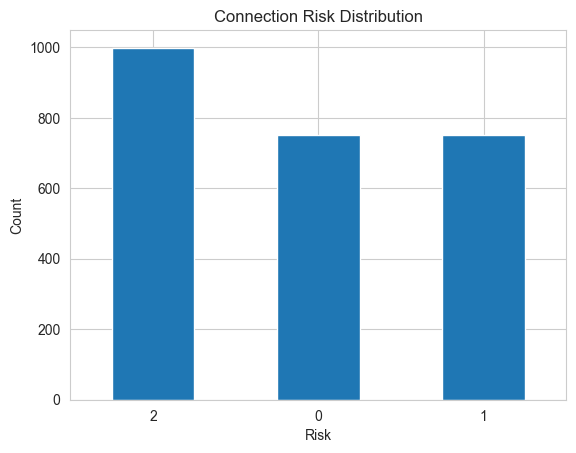

In [39]:
print(df["risk_label"].value_counts())

df["risk_label"].value_counts().plot(kind="bar")
plt.title("Connection Risk Distribution")
plt.xlabel("Risk")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

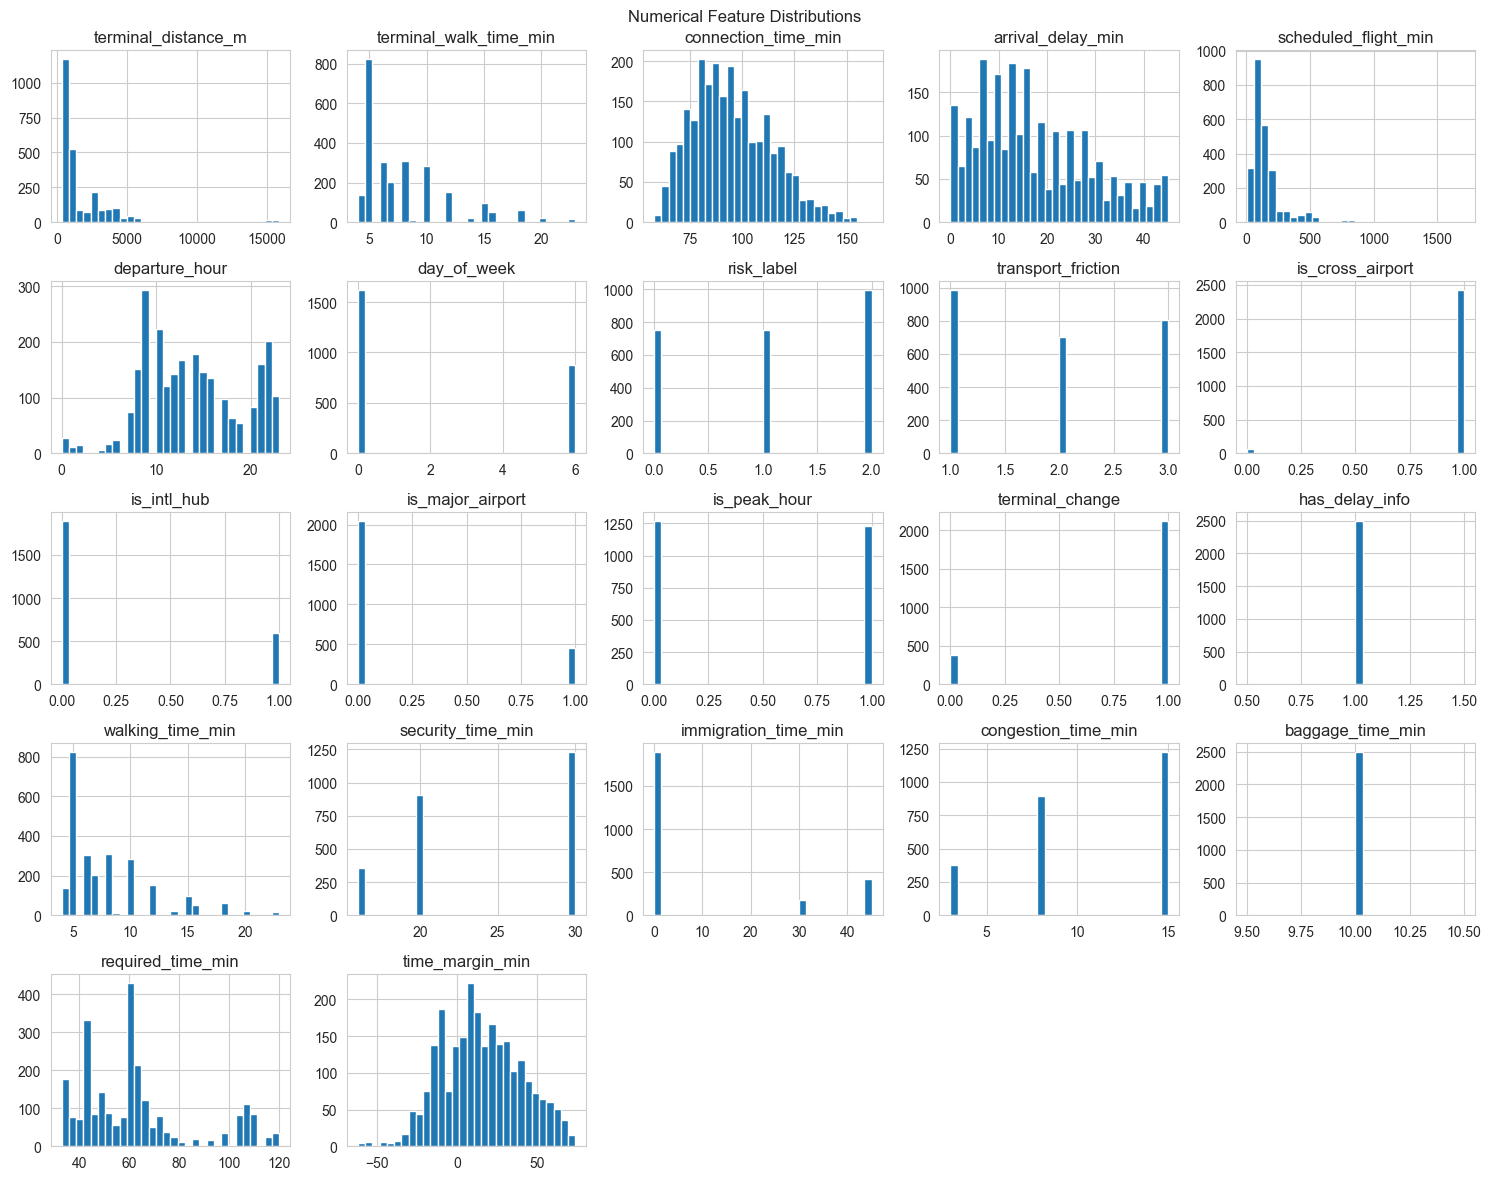

In [40]:
num_cols = df.select_dtypes(include=np.number).columns

df[num_cols].hist(figsize=(15, 12), bins=30)
plt.suptitle("Numerical Feature Distributions")
plt.tight_layout()
plt.show()

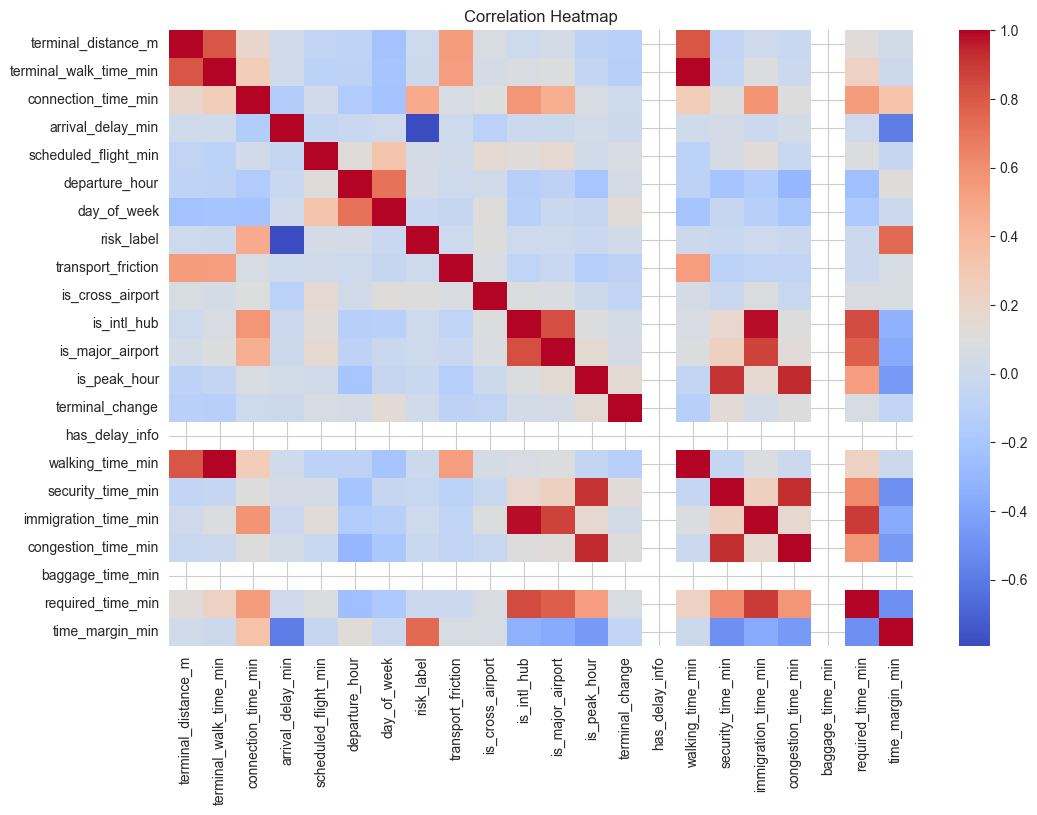

In [41]:
plt.figure(figsize=(12, 8))

# Select only numeric columns
num_df = df.select_dtypes(include=np.number)

sns.heatmap(num_df.corr(), cmap="coolwarm", annot=False)

plt.title("Correlation Heatmap")
plt.show()

In [42]:
print("\nDropping leakage and redundant columns...\n")

cols_to_drop = [
    "time_margin_min",       # leakage
    "terminal_walk_time_m",   # redundant
    "required_time_min"      # duplicate of components
]

df = df.drop(columns=cols_to_drop, errors="ignore")

print("Dropped:", cols_to_drop)
print("Shape:", df.shape)


Dropping leakage and redundant columns...

Dropped: ['time_margin_min', 'terminal_walk_time_m', 'required_time_min']
Shape: (2499, 32)


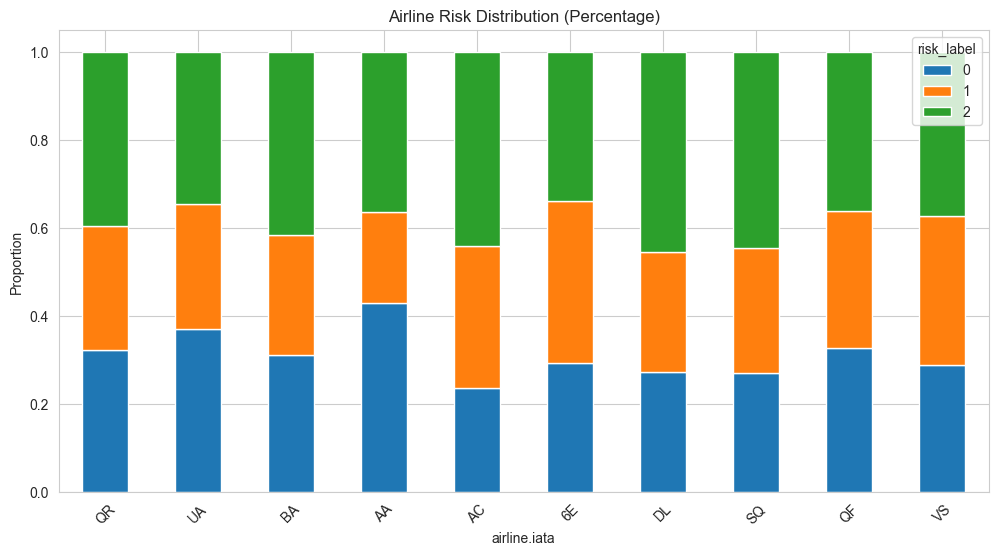

In [43]:
airline_risk = pd.crosstab(
    df["airline.iata"],
    df["risk_label"],
    normalize="index"
)

# Take top airlines only
airline_risk = airline_risk.loc[
    df["airline.iata"].value_counts().head(10).index
]

airline_risk.plot(kind="bar", stacked=True, figsize=(12,6))

plt.title("Airline Risk Distribution (Percentage)")
plt.ylabel("Proportion")
plt.xticks(rotation=45)
plt.show()

In [44]:
print("\nOutlier Treatment (IQR Method)\n")

import numpy as np


SKIP_COLS = {
    "connection_risk",      # target

    # Binary flags
    "is_cross_airport",
    "is_intl_hub",
    "is_major_airport",
    "is_peak_hour",
    "terminal_change",
    "has_delay_info",

    # Discrete engineered features
    "security_time_min",
    "immigration_time_min",
    "congestion_time_min",
    "baggage_time_min",
    "required_time_min"
}

outlier_summary = []

for col in df.select_dtypes(include=np.number).columns:
    
    if col in SKIP_COLS:
        continue

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((df[col] < lower) | (df[col] > upper)).sum()

    if outliers > 0:
        df[col] = df[col].clip(lower, upper)
        outlier_summary.append((col, outliers))

# 📊 Show summary
print("Columns where outliers were treated:\n")
for col, count in outlier_summary:
    print(f"{col:<30} → clipped {count}")

print("\nOutlier handling complete ✅")


Outlier Treatment (IQR Method)

Columns where outliers were treated:

terminal_distance_m            → clipped 61
terminal_walk_time_min         → clipped 99
connection_time_min            → clipped 14
scheduled_flight_min           → clipped 248
walking_time_min               → clipped 99

Outlier handling complete ✅


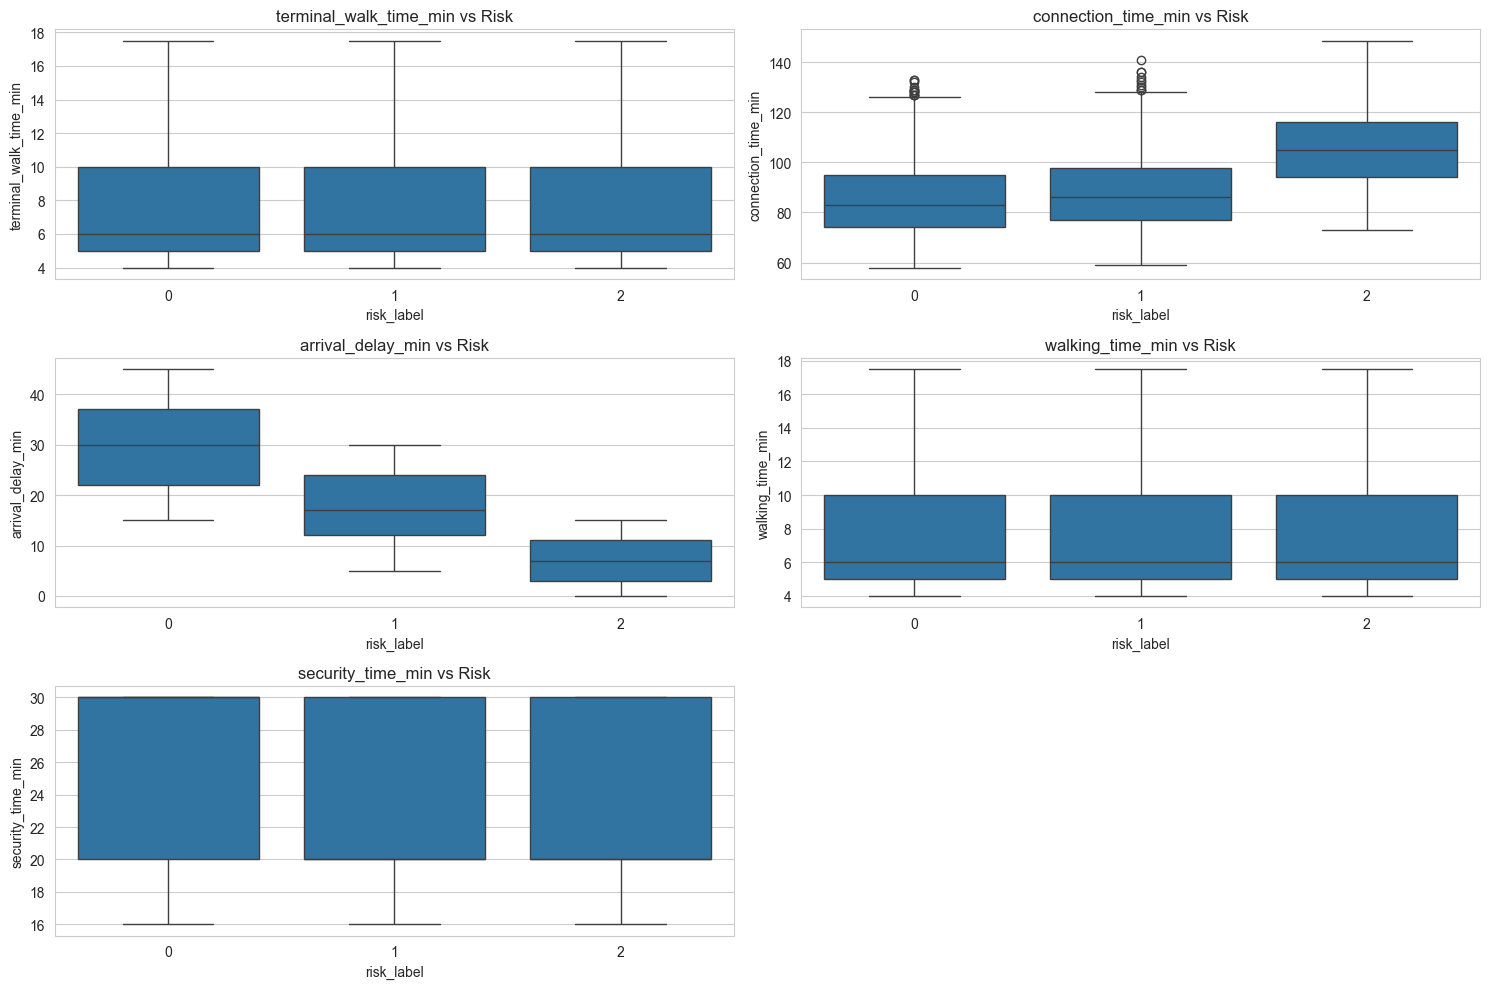

In [45]:
features = [
    "terminal_walk_time_min",
    "connection_time_min",
    "arrival_delay_min",
    "walking_time_min",
    "security_time_min"
]

plt.figure(figsize=(15,10))

for i, col in enumerate(features):
    plt.subplot(3, 2, i+1)
    sns.boxplot(x="risk_label", y=col, data=df)
    plt.title(f"{col} vs Risk")

plt.tight_layout()
plt.show()

In [46]:
print("\nEncoding categorical features...\n")

from sklearn.preprocessing import LabelEncoder

label_encoders = {}

for col in df.select_dtypes(include="object").columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le
    print(f"{col:<30} → encoded")

print("\nEncoding complete ✅")


Encoding categorical features...

flight_date                    → encoded
departure.iata                 → encoded
departure.terminal             → encoded
departure.gate                 → encoded
departure.scheduled            → encoded
arrival.iata                   → encoded
arrival.terminal               → encoded
arrival.scheduled              → encoded
airline.iata                   → encoded
terminal_transport_method      → encoded
security_crowd                 → encoded
immigration_crowd              → encoded

Encoding complete ✅


C:\Users\dines\AppData\Local\Temp\ipykernel_48932\355070593.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


In [47]:
df.to_csv("preprocessing1.csv", index=False)